In [1]:
import bff
from pathlib import Path

In [2]:
qoi_dir = Path('../04-qoi-custom-routine').resolve()
trainset_dir = Path('../03-training-trjs/c36-ecc80-00').resolve()
fn_specs = trainset_dir / 'specs.yaml'

datasets = [
    bff.qoi.data.QoIDataset.load(qoi_dir / 'qoi-rdf.pt'),
    bff.qoi.data.QoIDataset.load(qoi_dir / 'qoi-hb.pt'),
    bff.qoi.data.QoIDataset.load(qoi_dir / 'qoi-dist.pt'),
    ]
qoi = ['rdf', 'hb', 'dist']
charge_constraint = bff.domain.ChargeConstraint(fn_specs)

In [4]:
models = bff.bayes.learning.train_surrogates(
    datasets,
    y_means={'rdf': 'sigmoid', 'hb': 0, 'dist': 0},
    n_hyper_max=200,
    committee_size=1,
    test_fraction=0.2,
    device='cpu',
)
problem = bff.bayes.learning.InferenceProblem.from_datasets(
    models,
    datasets,
    qoi=qoi,
    constraint=charge_constraint,
)
results = problem.infer(
    priors_disttype='normal',
    total_steps=2000,
    fn_checkpoint='mcmc-checkpoint.pt',
    fn_posterior='posterior.pt',
    fn_priors='priors.pt',
    restart=False,
    device='cpu',
    rhat_tol=1.2,
)

=== Optimizing LGP surrogates ===                                                                   
                                                                                                    
> QoI: rdf                                                                                            
  - learning rate search: Done. | lr = 5.0e-04                                                          
  - MAP search: Done.                                                                                   
  - Committee: 1 (100%) | MAPE = 3.14%                                                                  
                                                                                                    
> QoI: hb                                                                                             
  - learning rate search: Done. | lr = 5.0e-02                                                          
  - MAP search: Done.                                                  

In [5]:
# Prepare posterior samples for visualization.
# This acetate example uses a short chain, so keep all saved samples.
results.prepare_samples(discard=0, thin=1)

specs = bff.domain.Specs(fn_specs)
marginal_labels = [
    name.split(maxsplit=1)[-1] for name in specs.bounds.names.tolist()
]
explicit_param_names = list(specs.parameter_names(explicit_only=True))
explicit_labels = [
    name.split(maxsplit=1)[-1] for name in explicit_param_names
]
nuisance_labels = [
    f"$\\sigma_{{\\mathrm{{{name.removeprefix('log_sigma_')}}}}}$"
    for name in results.priors.names
    if name.startswith('log_sigma_')
]
corner_labels = explicit_labels + nuisance_labels

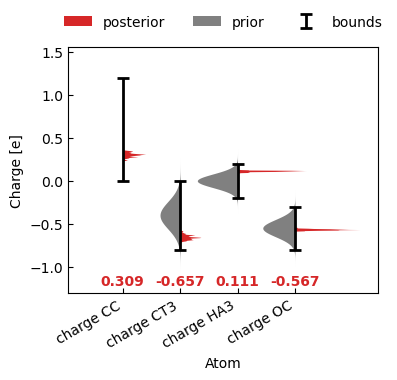

In [6]:
bff.plotting.plot_marginals(
    results,
    specs,
    parameter_labels=marginal_labels,
)

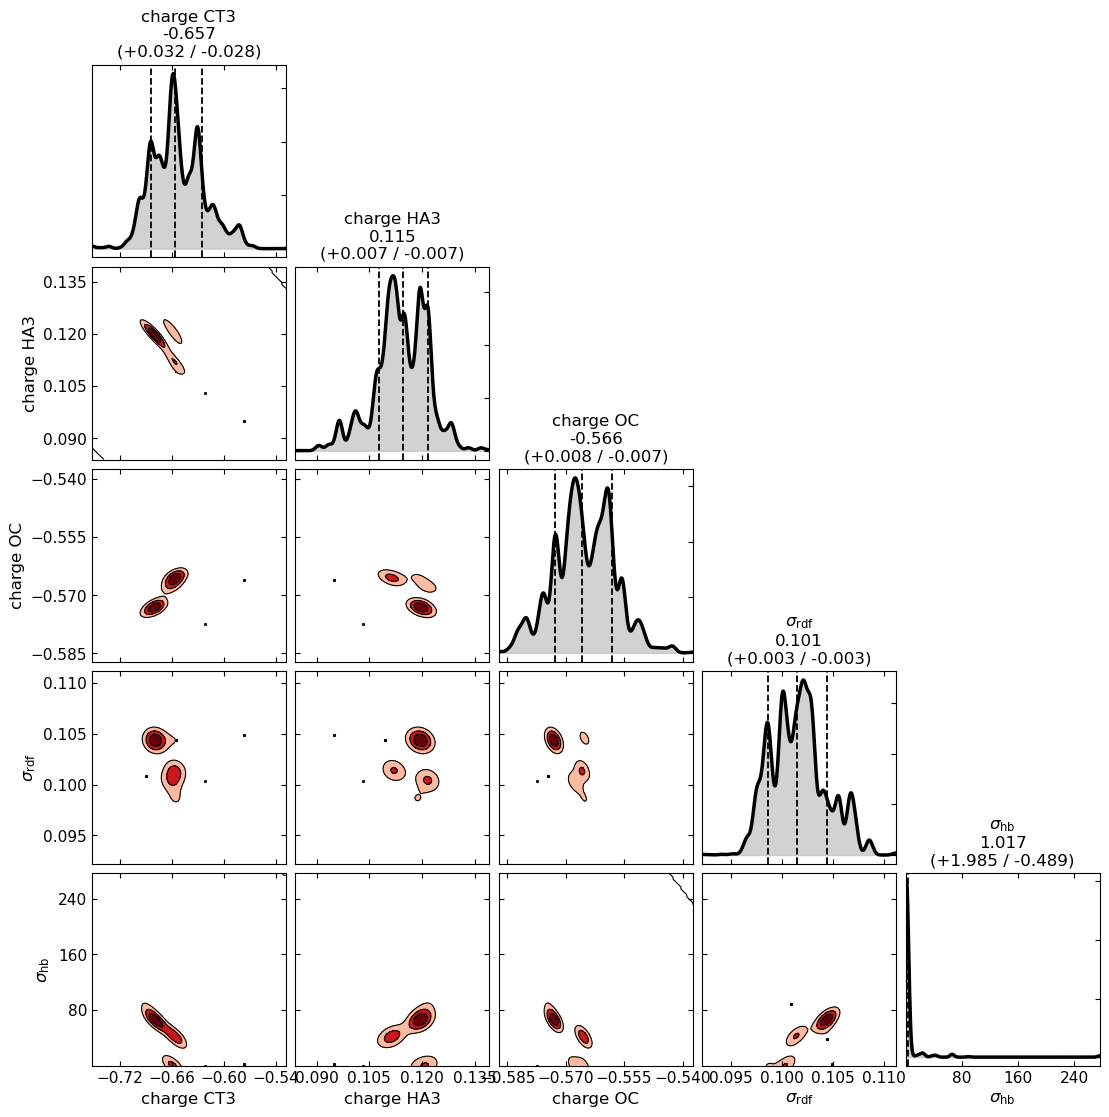

In [7]:
bff.plotting.plot_corner(results, labels=corner_labels)

In [15]:
# Save posterior samples
samples = results.sample_posterior(
    10,
    fn_out='./posterior-samples.yaml',
    overwrite=True,
)

In [16]:
# Modify and save a topology file with the first posterior sample
fn_top = trainset_dir / 'window-000.top'
top = bff.topology.TopologyModifier(
    fn_top,
    specs.mol_resname,
    specs.implicit_atoms
)

n_explicit = len(explicit_param_names)
new_params = dict(zip(explicit_param_names, samples[0][:n_explicit]))
top.apply_parameters(new_params, constraint_charge=None)
top.write('./topol-sample-001.top', overwrite=True)